In [3]:
import torch
import torch.nn as nn
from torchvision import models

class DINOModel(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # Remove FC layer
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 2048),
            nn.GELU(),
            nn.Linear(2048, 2048),
            nn.GELU(),
            nn.Linear(2048, 512),
        )

    def forward(self, x):
        x = self.backbone(x)  # shape: (batch, 512, 1, 1)
        x = self.projector(x)
        return x

In [4]:
model = DINOModel()
model.load_state_dict(torch.load("/app/notebooks/dino_radicals_resnet.pth", map_location=torch.device('cpu')))
model.eval()

/usr/local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DINOModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

🔍 Radical Image Attention


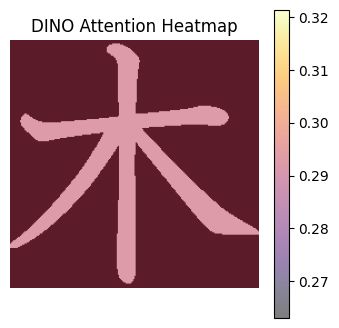

🌳 Full Kanji Image Attention


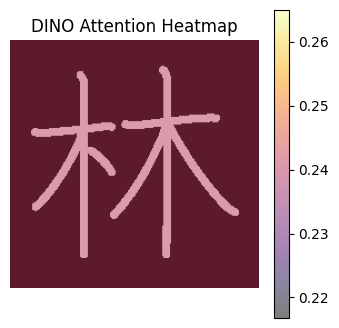

In [12]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Load trained model
model = DINOModel()
model.load_state_dict(torch.load("/app/notebooks/dino_radicals_resnet.pth"))
model.eval()

# Choose your radical and kanji image paths
radical_path = "/app/data/radicals/ki.png" 
kanji_path = "/app/data/jouyou/06797.png" # 067ca

# Use same transform as in dataset (without augmentations)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def get_attention_map(img_path):
    img = Image.open(img_path).convert("L")
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    with torch.no_grad():
        feature_map = model.backbone(img_tensor)[0]  # shape: [512, 1, 1]
    return feature_map.squeeze()

def visualize_attention_on_image(img_path, feature_vector):
    img = Image.open(img_path).convert("L").resize((224, 224))
    img_tensor = transform(img).unsqueeze(0)

    # Attention proxy: just visualizing the feature vector's absolute values as heat
    attn = feature_vector.abs().cpu().numpy()
    heatmap = (attn - attn.min()) / (attn.max() - attn.min() + 1e-6)

    # Since ResNet output is a global vector, we can’t do patch-level map directly.
    # Instead, simulate attention strength by rescaling the feature vector into a uniform heatmap.
    heatmap_image = np.ones((224, 224)) * heatmap.mean()

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.imshow(img, cmap='gray')
    im = plt.imshow(heatmap_image, cmap='inferno', alpha=0.5)
    plt.colorbar(im)
    plt.title("DINO Attention Heatmap")
    plt.axis('off')
    plt.show()

# Run for both radical and kanji
radical_vec = get_attention_map(radical_path)
kanji_vec = get_attention_map(kanji_path)

print("🔍 Radical Image Attention")
visualize_attention_on_image(radical_path, radical_vec)

print("🌳 Full Kanji Image Attention")
visualize_attention_on_image(kanji_path, kanji_vec)
